In [3]:
import os, random, shutil

SRC = './data/real_vs_fake/real-vs-fake'
DST = './data/subset'

In [4]:
random.seed(42)

def make_subset(split, n_per_class):
    for label in ['real', 'fake']:
        src_dir = os.path.join(SRC, split, label)
        dst_dir = os.path.join(DST, split, label)
        os.makedirs(dst_dir, exist_ok=True)
        files = os.listdir(src_dir)
        chosen = random.sample(files, min(n_per_class, len(files)))
        for f in chosen:
            shutil.copy(os.path.join(src_dir, f), os.path.join(dst_dir, f))

make_subset('train', 1500)
make_subset('valid', 300)
make_subset('test', 300)

print("Subset built.")

Subset built.


In [5]:
from facenet_pytorch import MTCNN
from PIL import Image
import torch

device = 'cuda' if torch.cuda.is_available() else 'cpu'
mtcnn = MTCNN(image_size=224, margin=20, post_process=False, device=device)

def crop_face(img_path, out_path):
    img = Image.open(img_path).convert('RGB')
    face = mtcnn(img)
    if face is None:
        img.resize((224, 224)).save(out_path)
    else:
        face_img = face.permute(1, 2, 0).byte().numpy()
        Image.fromarray(face_img).save(out_path)

C:\Users\VICTUS\OneDrive\Desktop\deepfake-detector\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
CROPPED = './data/subset_cropped'

for split in ['train', 'valid', 'test']:
    for label in ['real', 'fake']:
        src_dir = os.path.join(DST, split, label)
        dst_dir = os.path.join(CROPPED, split, label)
        os.makedirs(dst_dir, exist_ok=True)
        for f in os.listdir(src_dir):
            crop_face(os.path.join(src_dir, f), os.path.join(dst_dir, f))

print("Cropping done.")

Cropping done.


In [7]:
for split in ['train', 'valid', 'test']:
    for label in ['real', 'fake']:
        path = os.path.join(CROPPED, split, label)
        print(path, len(os.listdir(path)))

./data/subset_cropped\train\real 1500
./data/subset_cropped\train\fake 1500
./data/subset_cropped\valid\real 300
./data/subset_cropped\valid\fake 300
./data/subset_cropped\test\real 300
./data/subset_cropped\test\fake 300


In [8]:
from torchvision import transforms, datasets
from torch.utils.data import DataLoader

IMG_SIZE = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

train_ds = datasets.ImageFolder(os.path.join(CROPPED, 'train'), transform=train_tf)
valid_ds = datasets.ImageFolder(os.path.join(CROPPED, 'valid'), transform=eval_tf)
test_ds  = datasets.ImageFolder(os.path.join(CROPPED, 'test'),  transform=eval_tf)

train_dl = DataLoader(train_ds, batch_size=16, shuffle=True, num_workers=0)
valid_dl = DataLoader(valid_ds, batch_size=16, shuffle=False, num_workers=0)
test_dl  = DataLoader(test_ds,  batch_size=16, shuffle=False, num_workers=0)

In [9]:
import timm
import torch.nn as nn

model = timm.create_model('efficientnet_b0', pretrained=True, num_classes=2)
model = model.to(device)

# Freeze backbone, train only the classifier head for this first baseline run
for name, param in model.named_parameters():
    if 'classifier' not in name and 'fc' not in name:
        param.requires_grad = False

In [10]:
import torch.optim as optim
from torch.cuda.amp import autocast, GradScaler

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)
scaler = GradScaler()

EPOCHS = 5

def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        if train:
            optimizer.zero_grad()
        with torch.set_grad_enabled(train):
            with autocast():
                outputs = model(imgs)
                loss = criterion(outputs, labels)
            if train:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
        total_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    return total_loss / total, correct / total

for epoch in range(EPOCHS):
    train_loss, train_acc = run_epoch(train_dl, train=True)
    val_loss, val_acc = run_epoch(valid_dl, train=False)
    print(f"Epoch {epoch+1}: train_loss={train_loss:.3f} train_acc={train_acc:.3f} "
          f"val_loss={val_loss:.3f} val_acc={val_acc:.3f}")

Epoch 1: train_loss=2.084 train_acc=0.504 val_loss=2.130 val_acc=0.498
Epoch 2: train_loss=1.984 train_acc=0.521 val_loss=2.066 val_acc=0.510
Epoch 3: train_loss=1.923 train_acc=0.521 val_loss=2.036 val_acc=0.530
Epoch 4: train_loss=1.818 train_acc=0.541 val_loss=1.869 val_acc=0.543
Epoch 5: train_loss=1.765 train_acc=0.551 val_loss=1.855 val_acc=0.542


In [11]:
trainable = [n for n, p in model.named_parameters() if p.requires_grad]
print("Trainable params:", len(trainable))
print(trainable[:5])

Trainable params: 2
['classifier.weight', 'classifier.bias']


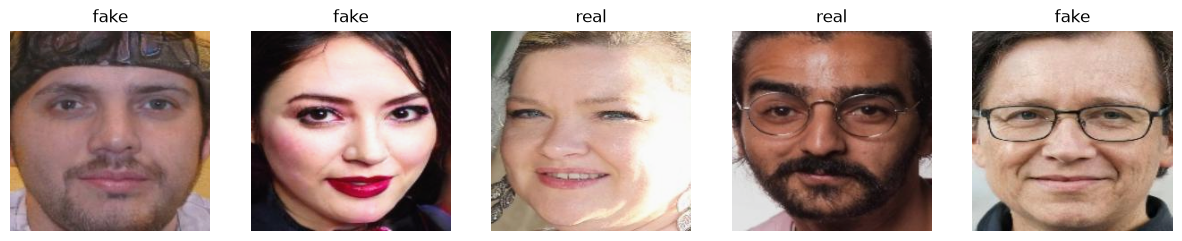

In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i, (imgs, labels) in enumerate(train_dl):
    for j in range(5):
        img = imgs[j].permute(1, 2, 0).numpy()
        img = img * IMAGENET_STD + IMAGENET_MEAN  # undo normalization for display
        img = img.clip(0, 1)
        axes[j].imshow(img)
        axes[j].set_title('fake' if labels[j].item() == 0 else 'real')
        axes[j].axis('off')
    break
plt.show()

In [13]:
model = timm.create_model('efficientnet_b0', pretrained=True, num_classes=2)
model = model.to(device)
# no freezing this time — every layer is trainable

In [14]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)  # now covers ALL params, not just head
scaler = GradScaler()

EPOCHS = 5

for epoch in range(EPOCHS):
    train_loss, train_acc = run_epoch(train_dl, train=True)
    val_loss, val_acc = run_epoch(valid_dl, train=False)
    print(f"Epoch {epoch+1}: train_loss={train_loss:.3f} train_acc={train_acc:.3f} "
          f"val_loss={val_loss:.3f} val_acc={val_acc:.3f}")

Epoch 1: train_loss=1.142 train_acc=0.716 val_loss=0.851 val_acc=0.758
Epoch 2: train_loss=0.377 train_acc=0.882 val_loss=0.680 val_acc=0.797
Epoch 3: train_loss=0.177 train_acc=0.938 val_loss=0.615 val_acc=0.817
Epoch 4: train_loss=0.138 train_acc=0.958 val_loss=0.610 val_acc=0.818
Epoch 5: train_loss=0.093 train_acc=0.967 val_loss=0.699 val_acc=0.832


In [15]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for imgs, labels in test_dl:
        imgs = imgs.to(device)
        outputs = model(imgs)
        probs = torch.softmax(outputs, dim=1)[:, 0]  # index 0 = "fake" per your class_to_idx mapping
        preds = outputs.argmax(dim=1).cpu()
        all_preds.extend(preds.tolist())
        all_labels.extend(labels.tolist())
        all_probs.extend(probs.cpu().tolist())

print(classification_report(all_labels, all_preds, target_names=['fake', 'real']))
print("Confusion matrix:\n", confusion_matrix(all_labels, all_preds))
print("AUC-ROC:", roc_auc_score([1 - l for l in all_labels], all_probs))

              precision    recall  f1-score   support

        fake       0.79      0.83      0.81       300
        real       0.82      0.78      0.80       300

    accuracy                           0.81       600
   macro avg       0.81      0.80      0.80       600
weighted avg       0.81      0.81      0.80       600

Confusion matrix:
 [[249  51]
 [ 66 234]]
AUC-ROC: 0.8988055555555554


In [16]:
torch.save(model.state_dict(), './efficientnet_b0_baseline.pth')
print("Model saved.")

Model saved.


In [17]:
import numpy, torch
print("numpy:", numpy.__version__)
print("torch:", torch.__version__, torch.cuda.is_available())

from facenet_pytorch import MTCNN
print("facenet-pytorch imported fine")

import cv2
print("opencv imported fine:", cv2.__version__)

from pytorch_grad_cam import GradCAM
print("grad-cam imported fine")

numpy: 1.26.4
torch: 2.2.2+cu121 True
facenet-pytorch imported fine
opencv imported fine: 5.0.0
grad-cam imported fine


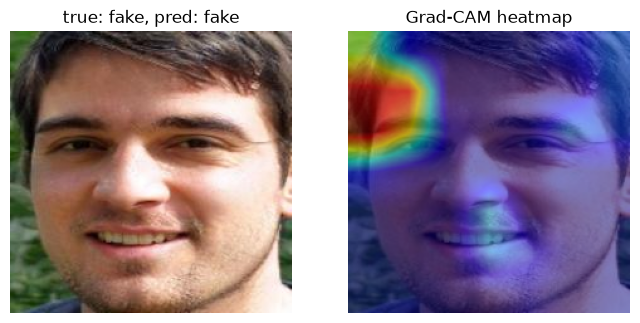

In [18]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
import numpy as np
import matplotlib.pyplot as plt

target_layer = [model.conv_head]
cam = GradCAM(model=model, target_layers=target_layer)

imgs, labels = next(iter(test_dl))
img_tensor = imgs[0:1].to(device)

# target the class the model actually predicted for this image
with torch.no_grad():
    pred_class = model(img_tensor).argmax(dim=1).item()

targets = [ClassifierOutputTarget(pred_class)]
grayscale_cam = cam(input_tensor=img_tensor, targets=targets)[0]

img_display = imgs[0].permute(1, 2, 0).numpy()
img_display = img_display * np.array(IMAGENET_STD) + np.array(IMAGENET_MEAN)
img_display = img_display.clip(0, 1)

visualization = show_cam_on_image(img_display, grayscale_cam, use_rgb=True)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(img_display)
true_label = 'fake' if labels[0].item() == 0 else 'real'
pred_label = 'fake' if pred_class == 0 else 'real'
axes[0].set_title(f'true: {true_label}, pred: {pred_label}')
axes[0].axis('off')
axes[1].imshow(visualization)
axes[1].set_title('Grad-CAM heatmap')
axes[1].axis('off')
plt.show()

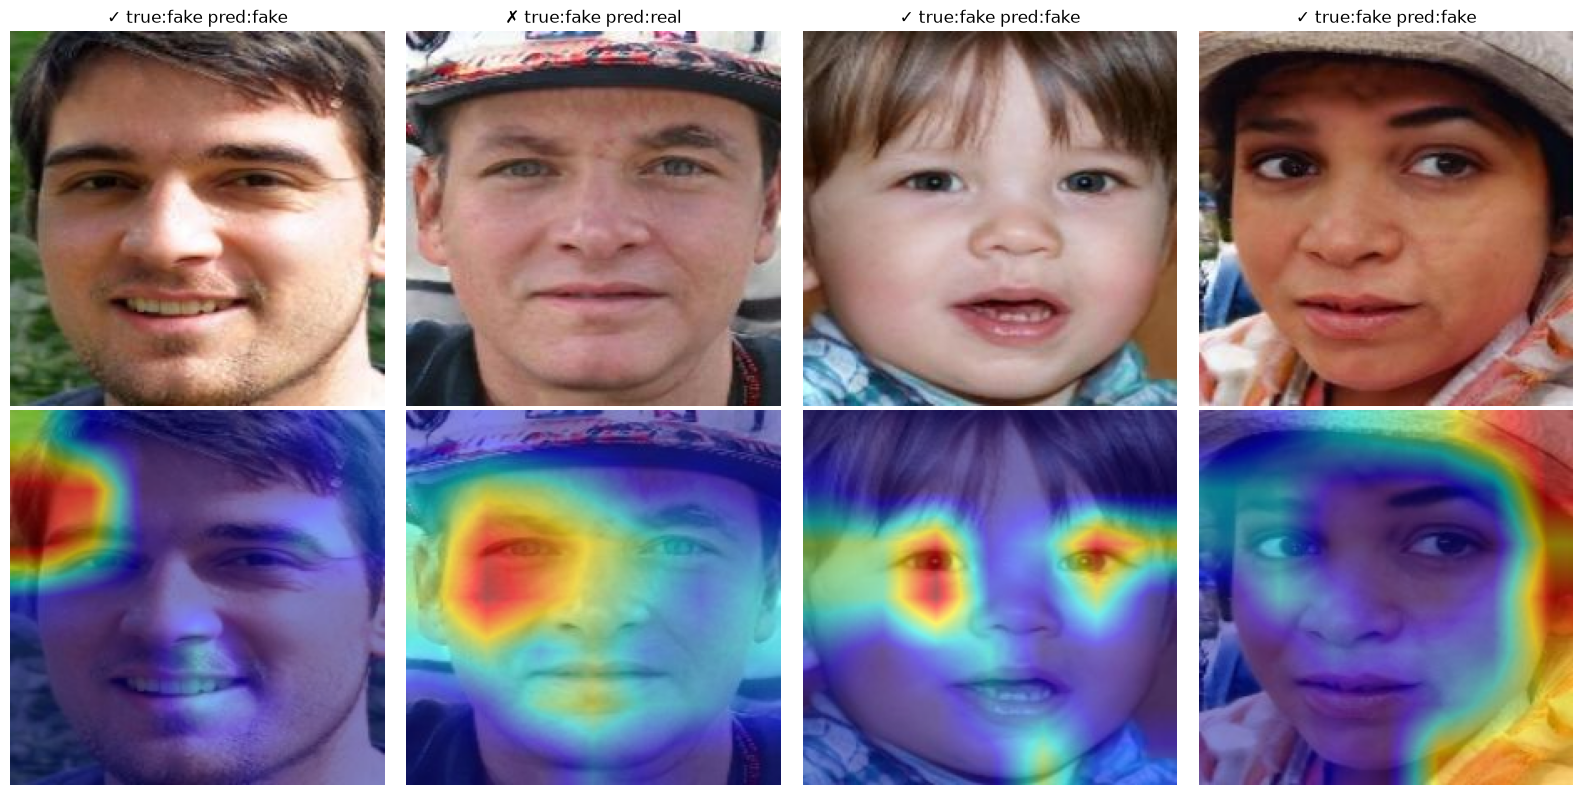

In [19]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i in range(4):
    img_tensor = imgs[i:i+1].to(device)
    with torch.no_grad():
        pred_class = model(img_tensor).argmax(dim=1).item()
    targets = [ClassifierOutputTarget(pred_class)]
    grayscale_cam = cam(input_tensor=img_tensor, targets=targets)[0]

    img_display = imgs[i].permute(1, 2, 0).numpy()
    img_display = img_display * np.array(IMAGENET_STD) + np.array(IMAGENET_MEAN)
    img_display = img_display.clip(0, 1)
    visualization = show_cam_on_image(img_display, grayscale_cam, use_rgb=True)

    true_label = 'fake' if labels[i].item() == 0 else 'real'
    pred_label = 'fake' if pred_class == 0 else 'real'
    correct = "✓" if true_label == pred_label else "✗"

    axes[0][i].imshow(img_display)
    axes[0][i].set_title(f'{correct} true:{true_label} pred:{pred_label}')
    axes[0][i].axis('off')
    axes[1][i].imshow(visualization)
    axes[1][i].axis('off')

plt.tight_layout()
plt.show()

In [20]:
import numpy as np

def compute_fft_features(img_tensor):
    # img_tensor: (C, H, W), already normalized
    # convert to grayscale by averaging channels
    gray = img_tensor.mean(dim=0).numpy()
    
    f = np.fft.fft2(gray)
    fshift = np.fft.fftshift(f)
    magnitude = np.log(np.abs(fshift) + 1e-8)
    
    # reduce to a compact feature vector: radial average (captures overall frequency energy distribution)
    h, w = magnitude.shape
    center = (h // 2, w // 2)
    y, x = np.indices((h, w))
    r = np.sqrt((x - center[1])**2 + (y - center[0])**2).astype(int)
    
    radial_mean = np.bincount(r.ravel(), magnitude.ravel()) / np.bincount(r.ravel())
    
    # downsample to a fixed-length vector (e.g. 32 bins) regardless of image size
    bins = np.linspace(0, len(radial_mean), 33).astype(int)
    features = [radial_mean[bins[i]:bins[i+1]].mean() for i in range(32)]
    
    return np.array(features, dtype=np.float32)

In [21]:
imgs, labels = next(iter(test_dl))
feat = compute_fft_features(imgs[0])
print(feat.shape)
print(feat[:10])

(32,)
[8.389129  6.9499016 6.0139136 5.515432  5.0648413 4.6456356 4.3702946
 4.1487346 3.9144561 3.7727282]


In [22]:
from torch.utils.data import Dataset

class FFTAugmentedDataset(Dataset):
    def __init__(self, base_dataset):
        self.base = base_dataset

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        img, label = self.base[idx]
        fft_feat = compute_fft_features(img)
        return img, torch.tensor(fft_feat), label

train_ds_fft = FFTAugmentedDataset(train_ds)
valid_ds_fft = FFTAugmentedDataset(valid_ds)
test_ds_fft  = FFTAugmentedDataset(test_ds)

train_dl_fft = DataLoader(train_ds_fft, batch_size=16, shuffle=True, num_workers=0)
valid_dl_fft = DataLoader(valid_ds_fft, batch_size=16, shuffle=False, num_workers=0)
test_dl_fft  = DataLoader(test_ds_fft,  batch_size=16, shuffle=False, num_workers=0)

In [23]:
import torch.nn as nn

class DualBranchModel(nn.Module):
    def __init__(self, cnn_backbone, fft_dim=32, num_classes=2):
        super().__init__()
        self.cnn = cnn_backbone
        # remove the CNN's own classifier, we'll build a combined one
        cnn_feat_dim = self.cnn.classifier.in_features
        self.cnn.classifier = nn.Identity()

        self.fft_branch = nn.Sequential(
            nn.Linear(fft_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
        )

        self.combined_classifier = nn.Linear(cnn_feat_dim + 32, num_classes)

    def forward(self, img, fft_feat):
        cnn_out = self.cnn(img)          # (B, cnn_feat_dim)
        fft_out = self.fft_branch(fft_feat)  # (B, 32)
        combined = torch.cat([cnn_out, fft_out], dim=1)
        return self.combined_classifier(combined)

# build it using your already fine-tuned backbone
dual_model = DualBranchModel(model, fft_dim=32, num_classes=2).to(device)

In [24]:
imgs, fft_feats, labels = next(iter(train_dl_fft))
imgs, fft_feats = imgs.to(device), fft_feats.to(device)
out = dual_model(imgs, fft_feats)
print(out.shape)  # should be (batch_size, 2)

torch.Size([16, 2])


In [25]:
import torch.optim as optim
from torch.cuda.amp import autocast, GradScaler

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(dual_model.parameters(), lr=1e-4)
scaler = GradScaler()

EPOCHS = 5

def run_epoch_dual(loader, train=True):
    dual_model.train() if train else dual_model.eval()
    total_loss, correct, total = 0, 0, 0
    for imgs, fft_feats, labels in loader:
        imgs, fft_feats, labels = imgs.to(device), fft_feats.to(device), labels.to(device)
        if train:
            optimizer.zero_grad()
        with torch.set_grad_enabled(train):
            with autocast():
                outputs = dual_model(imgs, fft_feats)
                loss = criterion(outputs, labels)
            if train:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
        total_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    return total_loss / total, correct / total

for epoch in range(EPOCHS):
    train_loss, train_acc = run_epoch_dual(train_dl_fft, train=True)
    val_loss, val_acc = run_epoch_dual(valid_dl_fft, train=False)
    print(f"Epoch {epoch+1}: train_loss={train_loss:.3f} train_acc={train_acc:.3f} "
          f"val_loss={val_loss:.3f} val_acc={val_acc:.3f}")

Epoch 1: train_loss=0.336 train_acc=0.853 val_loss=0.286 val_acc=0.873
Epoch 2: train_loss=0.123 train_acc=0.957 val_loss=0.271 val_acc=0.872
Epoch 3: train_loss=0.094 train_acc=0.966 val_loss=0.265 val_acc=0.900
Epoch 4: train_loss=0.059 train_acc=0.979 val_loss=0.287 val_acc=0.907
Epoch 5: train_loss=0.038 train_acc=0.987 val_loss=0.285 val_acc=0.893


In [26]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

dual_model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for imgs, fft_feats, labels in test_dl_fft:
        imgs, fft_feats = imgs.to(device), fft_feats.to(device)
        outputs = dual_model(imgs, fft_feats)
        probs = torch.softmax(outputs, dim=1)[:, 0]  # "fake" probability, per your class_to_idx
        preds = outputs.argmax(dim=1).cpu()
        all_preds.extend(preds.tolist())
        all_labels.extend(labels.tolist())
        all_probs.extend(probs.cpu().tolist())

print(classification_report(all_labels, all_preds, target_names=['fake', 'real']))
print("Confusion matrix:\n", confusion_matrix(all_labels, all_preds))
print("AUC-ROC:", roc_auc_score([1 - l for l in all_labels], all_probs))

              precision    recall  f1-score   support

        fake       0.92      0.92      0.92       300
        real       0.92      0.92      0.92       300

    accuracy                           0.92       600
   macro avg       0.92      0.92      0.92       600
weighted avg       0.92      0.92      0.92       600

Confusion matrix:
 [[275  25]
 [ 24 276]]
AUC-ROC: 0.9706666666666666


In [27]:
torch.save(dual_model.state_dict(), './dual_branch_fft_model.pth')
print("Dual-branch model saved.")

Dual-branch model saved.


In [28]:
import os
for root, dirs, files in os.walk('./data/diffusion_faces'):
    print(root, len(files))

./data/diffusion_faces 0
./data/diffusion_faces\stable-diffusion-face-dataset 4
./data/diffusion_faces\stable-diffusion-face-dataset\.git 5
./data/diffusion_faces\stable-diffusion-face-dataset\.git\hooks 12
./data/diffusion_faces\stable-diffusion-face-dataset\.git\info 1
./data/diffusion_faces\stable-diffusion-face-dataset\.git\logs 1
./data/diffusion_faces\stable-diffusion-face-dataset\.git\logs\refs 0
./data/diffusion_faces\stable-diffusion-face-dataset\.git\logs\refs\heads 1
./data/diffusion_faces\stable-diffusion-face-dataset\.git\logs\refs\remotes 0
./data/diffusion_faces\stable-diffusion-face-dataset\.git\logs\refs\remotes\origin 1
./data/diffusion_faces\stable-diffusion-face-dataset\.git\objects 0
./data/diffusion_faces\stable-diffusion-face-dataset\.git\objects\pack 2
./data/diffusion_faces\stable-diffusion-face-dataset\.git\refs 0
./data/diffusion_faces\stable-diffusion-face-dataset\.git\refs\heads 1
./data/diffusion_faces\stable-diffusion-face-dataset\.git\refs\remotes 0
./da

In [29]:
import os, random, shutil

DIFF_SRC = './data/diffusion_faces/stable-diffusion-face-dataset/512'
DIFF_SUBSET = './data/diffusion_subset'

random.seed(42)
os.makedirs(DIFF_SUBSET, exist_ok=True)

all_files = []
for gender in ['man', 'woman']:
    folder = os.path.join(DIFF_SRC, gender)
    for f in os.listdir(folder):
        all_files.append(os.path.join(folder, f))

chosen = random.sample(all_files, 300)
for i, f in enumerate(chosen):
    shutil.copy(f, os.path.join(DIFF_SUBSET, f'diff_{i}.jpg'))

print(f"Copied {len(chosen)} diffusion-generated images.")

Copied 300 diffusion-generated images.


In [30]:
DIFF_CROPPED = './data/diffusion_subset_cropped'
os.makedirs(DIFF_CROPPED, exist_ok=True)

for f in os.listdir(DIFF_SUBSET):
    crop_face(os.path.join(DIFF_SUBSET, f), os.path.join(DIFF_CROPPED, f))

print("Diffusion faces cropped.")

Diffusion faces cropped.


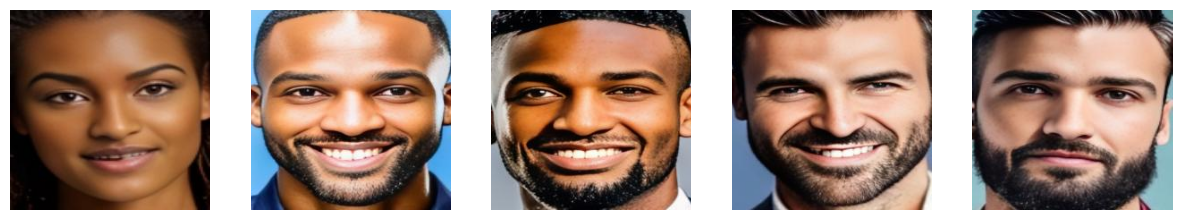

In [31]:
import matplotlib.pyplot as plt
from PIL import Image

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
files = os.listdir(DIFF_CROPPED)[:5]
for i, f in enumerate(files):
    img = Image.open(os.path.join(DIFF_CROPPED, f))
    axes[i].imshow(img)
    axes[i].axis('off')
plt.show()

In [32]:
from torchvision import transforms
from PIL import Image
import torch

eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

dual_model.eval()
correct = 0
total = 0
all_probs = []

with torch.no_grad():
    for f in os.listdir(DIFF_CROPPED):
        img = Image.open(os.path.join(DIFF_CROPPED, f)).convert('RGB')
        img_tensor = eval_tf(img)
        fft_feat = torch.tensor(compute_fft_features(img_tensor)).unsqueeze(0).to(device)
        img_tensor = img_tensor.unsqueeze(0).to(device)

        output = dual_model(img_tensor, fft_feat)
        prob_fake = torch.softmax(output, dim=1)[0, 0].item()
        pred = output.argmax(dim=1).item()

        all_probs.append(prob_fake)
        total += 1
        if pred == 0:  # 0 = fake, correct prediction since these ARE all fake
            correct += 1

print(f"Diffusion-generated faces correctly identified as FAKE: {correct}/{total} ({100*correct/total:.1f}%)")
print(f"Average 'fake' confidence: {sum(all_probs)/len(all_probs):.3f}")

Diffusion-generated faces correctly identified as FAKE: 12/300 (4.0%)
Average 'fake' confidence: 0.072


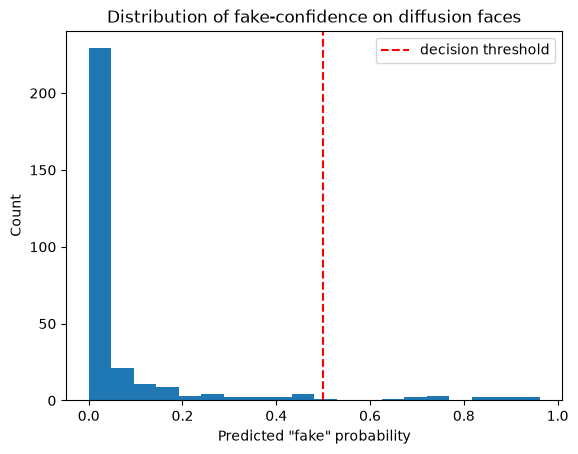

Min: 1.9061438649714546e-08 Max: 0.9616352915763855


In [33]:
import matplotlib.pyplot as plt

plt.hist(all_probs, bins=20)
plt.xlabel('Predicted "fake" probability')
plt.ylabel('Count')
plt.title('Distribution of fake-confidence on diffusion faces')
plt.axvline(0.5, color='red', linestyle='--', label='decision threshold')
plt.legend()
plt.show()

print("Min:", min(all_probs), "Max:", max(all_probs))

In [34]:
import json
with open('./generalization_test_results.json', 'w') as f:
    json.dump({
        "in_distribution_fake_recall": 0.90,
        "out_of_distribution_fake_recall": correct/total,
        "avg_fake_confidence_ood": sum(all_probs)/len(all_probs),
        "test_set": "Stable Diffusion Face Dataset (Kaggle)",
        "n_samples": total
    }, f, indent=2)
print("Saved.")

Saved.


In [35]:
import os

files_to_check = [
    './efficientnet_b0_baseline.pth',
    './dual_branch_fft_model.pth',
    './generalization_test_results.json'
]

for f in files_to_check:
    if os.path.exists(f):
        size_mb = os.path.getsize(f) / (1024 * 1024)
        print(f"✅ {f} — {size_mb:.1f} MB")
    else:
        print(f"❌ {f} — NOT FOUND")

✅ ./efficientnet_b0_baseline.pth — 15.6 MB
✅ ./dual_branch_fft_model.pth — 15.6 MB
✅ ./generalization_test_results.json — 0.0 MB


In [36]:
import os
for root, dirs, files in os.walk('./data/video_sample'):
    print(root, len(files), files[:3] if files else '')

./data/video_sample 0 
./data/video_sample\SDFVD Small-scale Deepfake Forgery Video Dataset 0 
./data/video_sample\SDFVD Small-scale Deepfake Forgery Video Dataset\SDFVD 0 
./data/video_sample\SDFVD Small-scale Deepfake Forgery Video Dataset\SDFVD\SDFVD 0 
./data/video_sample\SDFVD Small-scale Deepfake Forgery Video Dataset\SDFVD\SDFVD\videos_fake 53 ['vs1.mp4', 'vs10.mp4', 'vs11.mp4']
./data/video_sample\SDFVD Small-scale Deepfake Forgery Video Dataset\SDFVD\SDFVD\videos_real 53 ['v1.mp4', 'v10.mp4', 'v11.mp4']


In [37]:
VIDEO_REAL_DIR = './data/video_sample/SDFVD Small-scale Deepfake Forgery Video Dataset/SDFVD/SDFVD/videos_real'
VIDEO_FAKE_DIR = './data/video_sample/SDFVD Small-scale Deepfake Forgery Video Dataset/SDFVD/SDFVD/videos_fake'

test_video = os.path.join(VIDEO_FAKE_DIR, 'vs1.mp4')
print(os.path.exists(test_video))

True


In [38]:
import cv2

cap = cv2.VideoCapture(test_video)
fps = cap.get(cv2.CAP_PROP_FPS)
frame_count = cap.get(cv2.CAP_PROP_FRAME_COUNT)
width = cap.get(cv2.CAP_PROP_FRAME_WIDTH)
height = cap.get(cv2.CAP_PROP_FRAME_HEIGHT)

print(f"FPS: {fps}, Total frames: {frame_count}, Resolution: {int(width)}x{int(height)}")
cap.release()

FPS: 30.0, Total frames: 82.0, Resolution: 1280x720


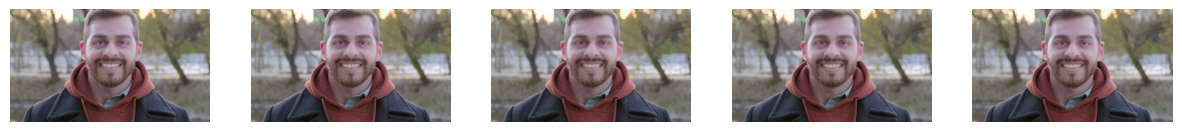

In [39]:
cap = cv2.VideoCapture(test_video)
frames = []

for i in range(5):
    ret, frame = cap.read()
    if not ret:
        break
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    frames.append(frame_rgb)

cap.release()

fig, axes = plt.subplots(1, len(frames), figsize=(15, 3))
for i, f in enumerate(frames):
    axes[i].imshow(f)
    axes[i].axis('off')
plt.show()

In [40]:
def predict_video(video_path, sample_every_n=10, max_frames=15):
    cap = cv2.VideoCapture(video_path)
    frame_idx = 0
    fake_probs = []

    while True:
        ret, frame = cap.read()
        if not ret:
            break
        if frame_idx % sample_every_n == 0:
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            img = Image.fromarray(frame_rgb)

            # crop face using your existing MTCNN pipeline
            face = mtcnn(img)
            if face is None:
                frame_idx += 1
                continue
            face_img = face.permute(1, 2, 0).byte().numpy()
            face_pil = Image.fromarray(face_img)

            # preprocess exactly like training
            img_tensor = eval_tf(face_pil)
            fft_feat = torch.tensor(compute_fft_features(img_tensor)).unsqueeze(0).to(device)
            img_tensor = img_tensor.unsqueeze(0).to(device)

            with torch.no_grad():
                output = dual_model(img_tensor, fft_feat)
                prob_fake = torch.softmax(output, dim=1)[0, 0].item()
            fake_probs.append(prob_fake)

            if len(fake_probs) >= max_frames:
                break
        frame_idx += 1

    cap.release()
    return fake_probs

In [41]:
probs = predict_video(test_video)
print(f"Sampled {len(probs)} frames")
print("Per-frame fake probabilities:", [f"{p:.2f}" for p in probs])
print(f"Average fake probability: {sum(probs)/len(probs):.3f}")
print(f"Verdict (majority vote): {'FAKE' if sum(probs)/len(probs) > 0.5 else 'REAL'}")

Sampled 9 frames
Per-frame fake probabilities: ['0.02', '0.00', '0.00', '0.00', '0.00', '0.00', '0.00', '0.00', '0.00']
Average fake probability: 0.002
Verdict (majority vote): REAL


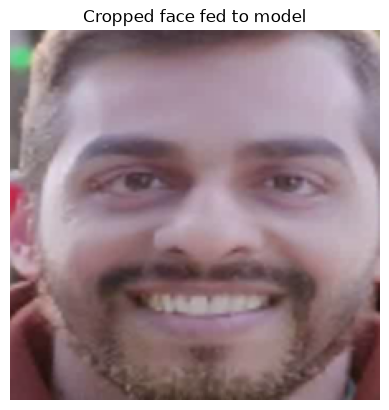

In [42]:
cap = cv2.VideoCapture(test_video)
ret, frame = cap.read()
cap.release()

frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
img = Image.fromarray(frame_rgb)
face = mtcnn(img)

if face is not None:
    face_img = face.permute(1, 2, 0).byte().numpy()
    plt.imshow(face_img)
    plt.axis('off')
    plt.title('Cropped face fed to model')
    plt.show()
else:
    print("No face detected in this frame")

In [43]:
test_video_real = os.path.join(VIDEO_REAL_DIR, 'v1.mp4')
probs_real = predict_video(test_video_real)
print(f"Sampled {len(probs_real)} frames")
print("Per-frame fake probabilities:", [f"{p:.2f}" for p in probs_real])
print(f"Average fake probability: {sum(probs_real)/len(probs_real):.3f}")
print(f"Verdict: {'FAKE' if sum(probs_real)/len(probs_real) > 0.5 else 'REAL'}")

Sampled 9 frames
Per-frame fake probabilities: ['0.04', '0.08', '0.00', '0.00', '0.01', '0.00', '0.08', '0.00', '0.00']
Average fake probability: 0.025
Verdict: REAL


In [44]:
import time

results = []
start = time.time()

for label, folder in [('fake', VIDEO_FAKE_DIR), ('real', VIDEO_REAL_DIR)]:
    for fname in os.listdir(folder):
        video_path = os.path.join(folder, fname)
        probs = predict_video(video_path, sample_every_n=15, max_frames=8)
        if len(probs) == 0:
            continue
        avg_prob = sum(probs) / len(probs)
        pred = 'fake' if avg_prob > 0.5 else 'real'
        results.append({'file': fname, 'true_label': label, 'avg_fake_prob': avg_prob, 'pred': pred})

print(f"Processed {len(results)} videos in {time.time()-start:.1f}s")

Processed 106 videos in 83.8s


In [45]:
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix

df = pd.DataFrame(results)
print(df.head())
print()

# accuracy, precision, recall, F1
print(classification_report(df['true_label'], df['pred']))
print("Confusion matrix (rows=true, cols=pred):")
print(confusion_matrix(df['true_label'], df['pred'], labels=['fake', 'real']))

print()
print("Average fake-probability by true label:")
print(df.groupby('true_label')['avg_fake_prob'].mean())

       file true_label  avg_fake_prob  pred
0   vs1.mp4       fake       0.003216  real
1  vs10.mp4       fake       0.000618  real
2  vs11.mp4       fake       0.034360  real
3  vs12.mp4       fake       0.033955  real
4  vs13.mp4       fake       0.008505  real

              precision    recall  f1-score   support

        fake       0.00      0.00      0.00        53
        real       0.50      1.00      0.67        53

    accuracy                           0.50       106
   macro avg       0.25      0.50      0.33       106
weighted avg       0.25      0.50      0.33       106

Confusion matrix (rows=true, cols=pred):
[[ 0 53]
 [ 0 53]]

Average fake-probability by true label:
true_label
fake    0.076301
real    0.032182
Name: avg_fake_prob, dtype: float64


C:\Users\VICTUS\OneDrive\Desktop\deepfake-detector\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\VICTUS\OneDrive\Desktop\deepfake-detector\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\VICTUS\OneDrive\Desktop\deepfake-detector\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(

In [46]:
df.to_csv('./video_test_results.csv', index=False)
print("Saved video test results.")

Saved video test results.


In [47]:
# Load pretrained checkpoints instead of retraining from scratch
model = timm.create_model('efficientnet_b0', pretrained=True, num_classes=2)
model = model.to(device)
model.load_state_dict(torch.load('./efficientnet_b0_baseline.pth'))
print("Phase 1 model loaded.")

dual_model = DualBranchModel(model, fft_dim=32, num_classes=2).to(device)
dual_model.load_state_dict(torch.load('./dual_branch_fft_model.pth'))
print("Phase 2 dual-branch model loaded.")

Phase 1 model loaded.
Phase 2 dual-branch model loaded.


In [48]:
model.eval()
dual_model.eval()

DualBranchModel(
  (cnn): EfficientNet(
    (conv_stem): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn1): BatchNormAct2d(
      32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): SiLU(inplace=True)
    )
    (blocks): Sequential(
      (0): Sequential(
        (0): DepthwiseSeparableConv(
          (conv_dw): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (bn1): BatchNormAct2d(
            32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
            (drop): Identity()
            (act): SiLU(inplace=True)
          )
          (aa): Identity()
          (se): SqueezeExcite(
            (conv_reduce): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (act1): SiLU(inplace=True)
            (conv_expand): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (gate): Sigmoid()
          )
          (conv_pw): Co

In [53]:
import random

random.seed(42)

fake_videos = os.listdir(VIDEO_FAKE_DIR)
real_videos = os.listdir(VIDEO_REAL_DIR)

random.shuffle(fake_videos)
random.shuffle(real_videos)

n_fake_train = int(len(fake_videos) * 0.8)
n_real_train = int(len(real_videos) * 0.8)

train_fake_videos = fake_videos[:n_fake_train]
test_fake_videos = fake_videos[n_fake_train:]
train_real_videos = real_videos[:n_real_train]
test_real_videos = real_videos[n_real_train:]

print(f"Train: {len(train_fake_videos)} fake, {len(train_real_videos)} real")
print(f"Test: {len(test_fake_videos)} fake, {len(test_real_videos)} real")

Train: 42 fake, 42 real
Test: 11 fake, 11 real


In [54]:
VIDEO_FRAMES_DIR = './data/video_frames'

def extract_training_frames(video_list, source_dir, label, split, frames_per_video=10):
    out_dir = os.path.join(VIDEO_FRAMES_DIR, split, label)
    os.makedirs(out_dir, exist_ok=True)
    
    for vid_name in video_list:
        video_path = os.path.join(source_dir, vid_name)
        cap = cv2.VideoCapture(video_path)
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        step = max(1, total_frames // frames_per_video)
        
        frame_idx = 0
        saved = 0
        while saved < frames_per_video:
            ret, frame = cap.read()
            if not ret:
                break
            if frame_idx % step == 0:
                frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                img = Image.fromarray(frame_rgb)
                face = mtcnn(img)
                if face is not None:
                    face_img = face.permute(1, 2, 0).byte().numpy()
                    out_path = os.path.join(out_dir, f"{vid_name}_{saved}.jpg")
                    Image.fromarray(face_img).save(out_path)
                    saved += 1
            frame_idx += 1
        cap.release()

extract_training_frames(train_fake_videos, VIDEO_FAKE_DIR, 'fake', 'train')
extract_training_frames(train_real_videos, VIDEO_REAL_DIR, 'real', 'train')
extract_training_frames(test_fake_videos, VIDEO_FAKE_DIR, 'fake', 'test')
extract_training_frames(test_real_videos, VIDEO_REAL_DIR, 'real', 'test')

print("Frame extraction done.")

Frame extraction done.


In [55]:
for split in ['train', 'test']:
    for label in ['real', 'fake']:
        path = os.path.join(VIDEO_FRAMES_DIR, split, label)
        print(path, len(os.listdir(path)))

./data/video_frames\train\real 418
./data/video_frames\train\fake 418
./data/video_frames\test\real 109
./data/video_frames\test\fake 110


In [56]:
video_train_ds = datasets.ImageFolder(os.path.join(VIDEO_FRAMES_DIR, 'train'), transform=train_tf)
video_test_ds = datasets.ImageFolder(os.path.join(VIDEO_FRAMES_DIR, 'test'), transform=eval_tf)

print(video_train_ds.class_to_idx)  # confirm fake=0, real=1 as before

video_train_dl = DataLoader(video_train_ds, batch_size=16, shuffle=True, num_workers=0)
video_test_dl = DataLoader(video_test_ds, batch_size=16, shuffle=False, num_workers=0)

{'fake': 0, 'real': 1}


In [57]:
video_train_ds_fft = FFTAugmentedDataset(video_train_ds)
video_test_ds_fft = FFTAugmentedDataset(video_test_ds)

video_train_dl_fft = DataLoader(video_train_ds_fft, batch_size=16, shuffle=True, num_workers=0)
video_test_dl_fft = DataLoader(video_test_ds_fft, batch_size=16, shuffle=False, num_workers=0)

In [58]:
dual_model.train()

optimizer = optim.Adam(dual_model.parameters(), lr=5e-5)  # lower LR than before, gentler fine-tune
scaler = GradScaler()

EPOCHS = 5

for epoch in range(EPOCHS):
    train_loss, train_acc = run_epoch_dual(video_train_dl_fft, train=True)
    val_loss, val_acc = run_epoch_dual(video_test_dl_fft, train=False)
    print(f"Epoch {epoch+1}: train_loss={train_loss:.3f} train_acc={train_acc:.3f} "
          f"val_loss={val_loss:.3f} val_acc={val_acc:.3f}")

Epoch 1: train_loss=0.762 train_acc=0.781 val_loss=0.690 val_acc=0.694
Epoch 2: train_loss=0.148 train_acc=0.937 val_loss=0.748 val_acc=0.699
Epoch 3: train_loss=0.102 train_acc=0.962 val_loss=0.819 val_acc=0.676
Epoch 4: train_loss=0.068 train_acc=0.978 val_loss=0.981 val_acc=0.635
Epoch 5: train_loss=0.041 train_acc=0.987 val_loss=0.966 val_acc=0.671


In [59]:
dual_model.train()
optimizer = optim.Adam(dual_model.parameters(), lr=5e-5)
scaler = GradScaler()

EPOCHS = 2  # stopping at the point where val accuracy was actually best

for epoch in range(EPOCHS):
    train_loss, train_acc = run_epoch_dual(video_train_dl_fft, train=True)
    val_loss, val_acc = run_epoch_dual(video_test_dl_fft, train=False)
    print(f"Epoch {epoch+1}: train_loss={train_loss:.3f} train_acc={train_acc:.3f} "
          f"val_loss={val_loss:.3f} val_acc={val_acc:.3f}")

Epoch 1: train_loss=0.044 train_acc=0.984 val_loss=1.027 val_acc=0.680
Epoch 2: train_loss=0.038 train_acc=0.988 val_loss=1.251 val_acc=0.626


In [60]:
# reload clean weights before re-fine-tuning
backbone = timm.create_model('efficientnet_b0', pretrained=True, num_classes=2)
backbone = backbone.to(device)
backbone.load_state_dict(torch.load('./efficientnet_b0_baseline.pth', map_location=device))

dual_model = DualBranchModel(backbone, fft_dim=32, num_classes=2).to(device)
dual_model.load_state_dict(torch.load('./dual_branch_fft_model.pth', map_location=device))

dual_model.train()
optimizer = optim.Adam(dual_model.parameters(), lr=5e-5)
scaler = GradScaler()

for epoch in range(2):
    train_loss, train_acc = run_epoch_dual(video_train_dl_fft, train=True)
    val_loss, val_acc = run_epoch_dual(video_test_dl_fft, train=False)
    print(f"Epoch {epoch+1}: train_loss={train_loss:.3f} train_acc={train_acc:.3f} "
          f"val_loss={val_loss:.3f} val_acc={val_acc:.3f}")

Epoch 1: train_loss=0.795 train_acc=0.756 val_loss=0.702 val_acc=0.721
Epoch 2: train_loss=0.163 train_acc=0.938 val_loss=0.849 val_acc=0.671


In [61]:
# reload clean Phase 2 weights
backbone = timm.create_model('efficientnet_b0', pretrained=True, num_classes=2)
backbone = backbone.to(device)
backbone.load_state_dict(torch.load('./efficientnet_b0_baseline.pth', map_location=device))

dual_model = DualBranchModel(backbone, fft_dim=32, num_classes=2).to(device)
dual_model.load_state_dict(torch.load('./dual_branch_fft_model.pth', map_location=device))

dual_model.train()
optimizer = optim.Adam(dual_model.parameters(), lr=5e-5)
scaler = GradScaler()

train_loss, train_acc = run_epoch_dual(video_train_dl_fft, train=True)
val_loss, val_acc = run_epoch_dual(video_test_dl_fft, train=False)
print(f"Epoch 1: train_loss={train_loss:.3f} train_acc={train_acc:.3f} "
      f"val_loss={val_loss:.3f} val_acc={val_acc:.3f}")

# save this as the final video-fine-tuned model
dual_model.eval()
torch.save(dual_model.state_dict(), './dual_branch_video_finetuned.pth')
print("Saved video-fine-tuned model.")

Epoch 1: train_loss=0.794 train_acc=0.769 val_loss=0.667 val_acc=0.717
Saved video-fine-tuned model.


In [62]:
model.eval()
dual_model.eval()

results_heldout = []
for label, video_list, folder in [
    ('fake', test_fake_videos, VIDEO_FAKE_DIR),
    ('real', test_real_videos, VIDEO_REAL_DIR)
]:
    for fname in video_list:
        video_path = os.path.join(folder, fname)
        probs = predict_video(video_path, sample_every_n=15, max_frames=8)
        if len(probs) == 0:
            continue
        avg_prob = sum(probs) / len(probs)
        pred = 'fake' if avg_prob > 0.5 else 'real'
        results_heldout.append({'file': fname, 'true_label': label, 'avg_fake_prob': avg_prob, 'pred': pred})

df_heldout = pd.DataFrame(results_heldout)
print(f"Evaluated on {len(df_heldout)} held-out videos (never seen during fine-tuning)")
print(classification_report(df_heldout['true_label'], df_heldout['pred']))
print("Confusion matrix (rows=true, cols=pred):")
print(confusion_matrix(df_heldout['true_label'], df_heldout['pred'], labels=['fake', 'real']))

Evaluated on 22 held-out videos (never seen during fine-tuning)
              precision    recall  f1-score   support

        fake       0.75      0.82      0.78        11
        real       0.80      0.73      0.76        11

    accuracy                           0.77        22
   macro avg       0.78      0.77      0.77        22
weighted avg       0.78      0.77      0.77        22

Confusion matrix (rows=true, cols=pred):
[[9 2]
 [3 8]]


In [63]:
df_heldout.to_csv('./video_finetuned_heldout_results.csv', index=False)
print("Saved.")

Saved.
